In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import joblib
import warnings

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# Load data 3D
print("Memuat dataset 3D...")
X_train = np.load('../processed/train_3d_features.npy')
y_train = np.load('../processed/train_3d_labels.npy')
X_test = np.load('../processed/test_3d_features.npy')
y_test = np.load('../processed/test_3d_labels.npy')

print(f"Bentuk X_train: {X_train.shape} (Samples, TimeSteps, Features)")
print(f"Bentuk y_train: {y_train.shape}")
print(f"Bentuk X_test : {X_test.shape}")
print(f"Bentuk y_test : {y_test.shape}")

Memuat dataset 3D...
Bentuk X_train: (17631, 30, 17) (Samples, TimeSteps, Features)
Bentuk y_train: (17631, 1)
Bentuk X_test : (100, 30, 17)
Bentuk y_test : (100,)


### Model LSTM

In [2]:
sequence_length = X_train.shape[1]
num_features = X_train.shape[2]

model = Sequential()

model.add(LSTM(
    units=50, 
    return_sequences=True, 
    input_shape=(sequence_length, num_features)
))
model.add(Dropout(0.2))

model.add(LSTM(
    units=50, 
    return_sequences=False
))
model.add(Dropout(0.2))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        13,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,851 (132.23 KB)

 Trainable params: 33,851 (132.23 KB)

 Non-trainable params: 0 (0.00 B)

None


### Training Model

In [3]:
TRAIN_MODEL = False 

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint_path = '../models/lstm_best_model.h5'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)

EPOCHS = 60
BATCH_SIZE = 200 
VALIDATION_SPLIT = 0.1 

if TRAIN_MODEL:
    print("Mulai melatih model LSTM dari nol...")
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VALIDATION_SPLIT,
        callbacks=[early_stop, checkpoint],
        verbose=1
    )
    print("Pelatihan selesai dan model terbaik telah disimpan!")
else:
    print("Skip training: Kita akan menggunakan model yang sudah tersimpan di folder models.")

Skip training: Kita akan menggunakan model yang sudah tersimpan di folder models.


### Evaluasi & Plotting Loss Curve

Memuat bobot model terbaik dari folder models...
Model berhasil dipulihkan! Siap untuk evaluasi.
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step

=== Evaluasi LSTM (Data Uji) ===
RMSE       : 15.5184
MAE        : 12.2577
R2 Score   : 0.8605
NASA Score : 349.3415


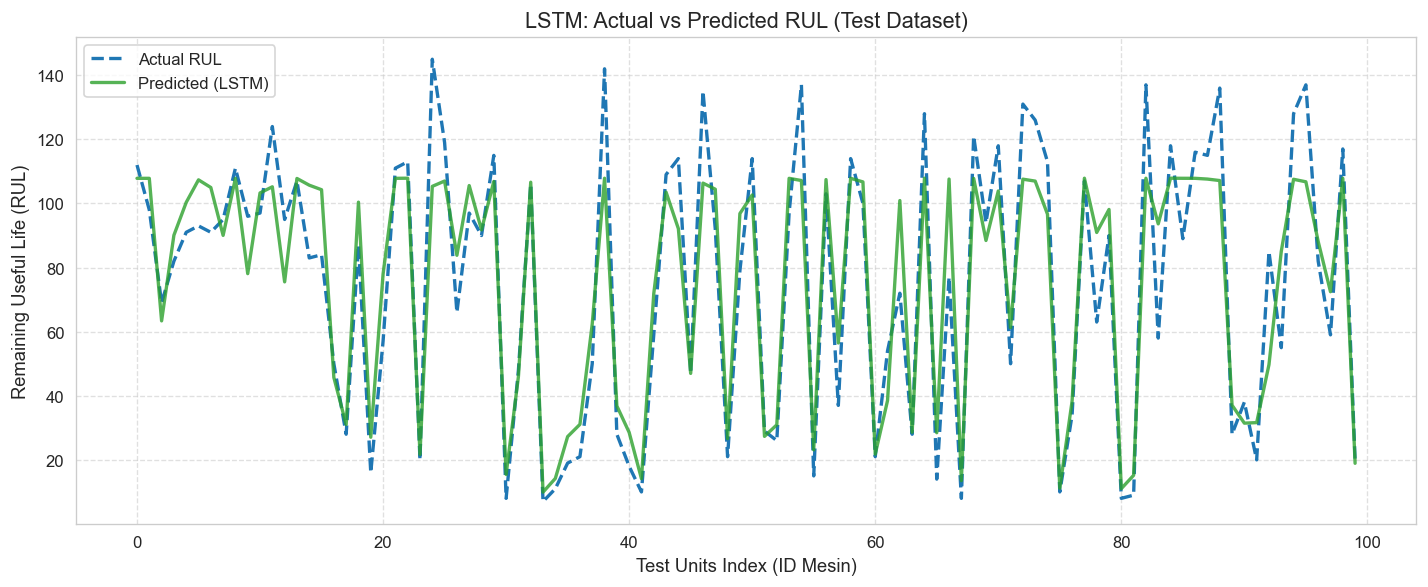

Semua evaluasi dan grafik berhasil disimpan!


In [4]:
if os.path.exists('../models/lstm_best_model.h5'):
    print("Memuat bobot model terbaik dari folder models...")
    model.load_weights('../models/lstm_best_model.h5')
    print("Model berhasil dipulihkan! Siap untuk evaluasi.")
else:
    print("File model tidak ditemukan.")

# 2. Fungsi Evaluasi
def evaluate_model(y_true, y_pred, model_name='Model'):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    
    # NASA scoring function
    def nasa_score(y_true, y_pred):
        diff = y_pred - y_true
        score = np.sum(np.where(diff < 0, np.exp(-diff/13) - 1, np.exp(diff/10) - 1))
        return score
    
    ns = nasa_score(y_true, y_pred)
    
    print(f'\n=== Evaluasi {model_name} (Data Uji) ===')
    print(f'RMSE       : {rmse:.4f}')
    print(f'MAE        : {mae:.4f}')
    print(f'R2 Score   : {r2:.4f}')
    print(f'NASA Score : {ns:.4f}')
    return {'RMSE': float(rmse), 'MAE': float(mae), 'R2': float(r2), 'NASA_Score': float(ns)}

# 3. Prediksi Data Test
y_pred_lstm = model.predict(X_test).flatten()
metrics_lstm = evaluate_model(y_test, y_pred_lstm, model_name='LSTM')

# 4. Plot Prediksi vs Aktual
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual RUL', linestyle='--', color='#1f77b4', linewidth=2)
plt.plot(y_pred_lstm, label='Predicted (LSTM)', color='#2ca02c', alpha=0.8, linewidth=2)

plt.title('LSTM: Actual vs Predicted RUL (Test Dataset)', fontsize=13)
plt.xlabel('Test Units Index (ID Mesin)', fontsize=11)
plt.ylabel('Remaining Useful Life (RUL)', fontsize=11)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('../output/lstm_pred_vs_actual_line.png', dpi=300)
plt.show()

# 5. Simpan metrik ke JSON
with open('../processed/lstm_metrics.json', 'w') as f:
    json.dump(metrics_lstm, f, indent=2)

print("Semua evaluasi dan grafik berhasil disimpan!")

### Explainable AI (XAI) dengan Integrated Gradients

Memuat daftar fitur dari train_2d.csv...
Menghitung Integrated Gradients untuk LSTM...


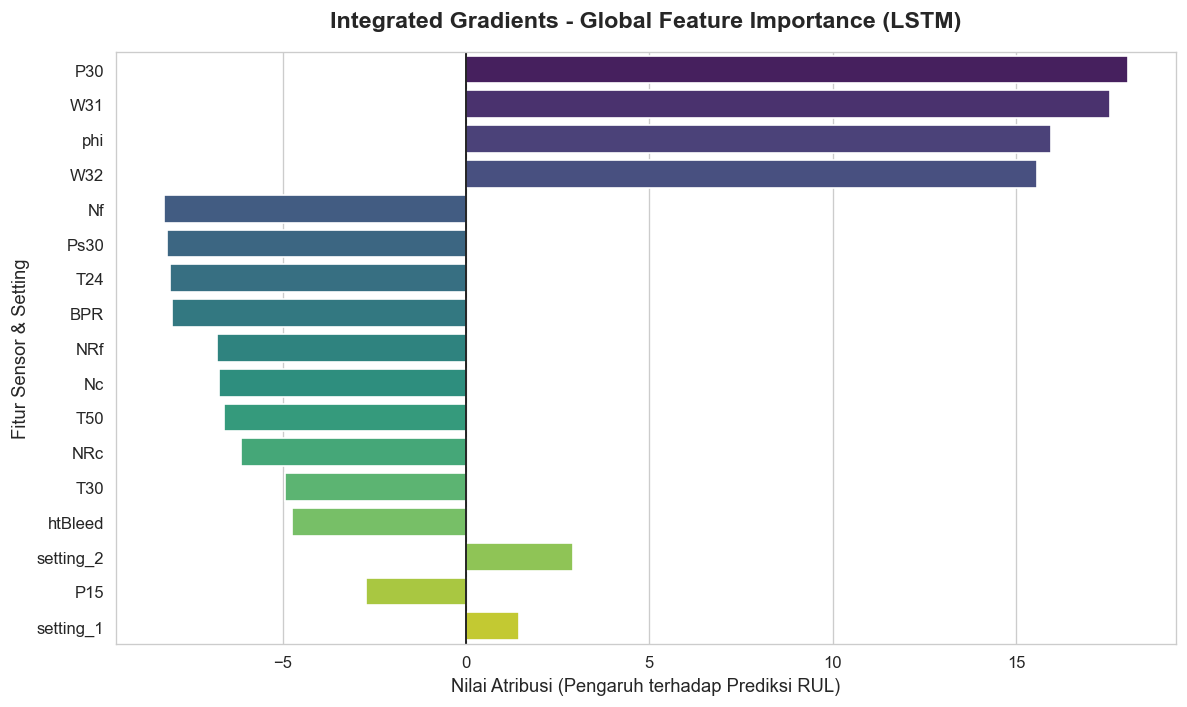

In [5]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def integrated_gradients(inputs, baseline, model, num_steps=50):
    # 1. Buat interpolasi antara baseline (nol) dan input aktual
    alphas = tf.linspace(start=0.0, stop=1.0, num=num_steps+1)
    alphas_x = alphas[:, tf.newaxis, tf.newaxis] 
    
    inputs = tf.cast(inputs, tf.float32)
    baseline = tf.cast(baseline, tf.float32)
    
    delta = inputs - baseline
    interpolated_inputs = baseline + alphas_x * delta

    # 2. Hitung gradien menggunakan GradientTape
    with tf.GradientTape() as tape:
        tape.watch(interpolated_inputs)
        preds = model(interpolated_inputs)
        
    grads = tape.gradient(preds, interpolated_inputs)
    
    # 3. Rata-ratakan gradien dan kalikan
    avg_grads = tf.reduce_mean(grads, axis=0)
    ig_attributions = delta * avg_grads
    return ig_attributions

print("Memuat daftar fitur dari train_2d.csv...")
df_train = pd.read_csv('../processed/train_2d.csv')

# Ambil semua kolom kecuali kolom identitas dan target
kolom_abaikan = ['unit_number', 'time_cycles', 'RUL', 'RUL_True']
active_features = [c for c in df_train.columns if c not in kolom_abaikan]

# Pengecekan Keamanan Dimensi
if len(active_features) != X_test.shape[2]:
    print(f"Jumlah nama fitur ({len(active_features)}) tidak sama dengan input LSTM ({X_test.shape[2]}).")
    # Fallback: Buat nama fitur default (Feature_1, Feature_2, dst)
    active_features = [f"Fitur_{i+1}" for i in range(X_test.shape[2])]
# ----------------------------------------

print("Menghitung Integrated Gradients untuk LSTM...")
# Ambil satu sampel mesin kritis
sample_idx = 0
sample_input = X_test[sample_idx:sample_idx+1] # Shape: (1, 30, n_features)
baseline_input = tf.zeros_like(sample_input)

# Hitung IG
ig_scores = integrated_gradients(sample_input, baseline_input, model)

# Sum pooling di sepanjang sumbu waktu
ig_scores_summed = tf.reduce_sum(ig_scores, axis=1)[0].numpy()

# Buat DataFrame untuk visualisasi
ig_df = pd.DataFrame({
    'Feature': active_features,
    'IG_Attribution': ig_scores_summed
}).sort_values(by='IG_Attribution', key=abs, ascending=False)

# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(data=ig_df, x='IG_Attribution', y='Feature', palette='viridis')
plt.title('Integrated Gradients - Global Feature Importance (LSTM)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nilai Atribusi (Pengaruh terhadap Prediksi RUL)', fontsize=11)
plt.ylabel('Fitur Sensor & Setting', fontsize=11)
plt.axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.savefig('../output/xai_integrated_gradients.png', dpi=300)
plt.show()